# Strategy 6: Calendar / Seasonality Effects

**Thesis.** Certain calendar periods have historically shown different
average returns than others — the turn-of-month effect (institutional
flows around month-end/month-start) and day-of-week effects in equities
are the two most commonly cited. This strategy uses no price history at
all, only the calendar date — a structurally different signal source from
every other strategy in this repo.

**Signal.** `stratlib.strategies.seasonality_signal`, two variants:
`turn_of_month` (long during the last trading day of the month through
the first 3 of the next) and `day_of_week` (long Monday/Tuesday only).

**A different kind of caution applies to this notebook specifically.**
Calendar effects are a textbook case of data-mining risk in finance
research — with enough candidate calendar patterns tested against enough
assets, some will look "significant" by chance alone. This notebook
tests 2 effects × 3 assets = 6 combinations, and treats that multiple-
comparisons context as part of the result, not an afterthought.


In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
%matplotlib inline

from stratlib.strategies import seasonality_signal
from stratlib.backtest import single_asset_backtest
from stratlib.robustness import walk_forward_validation
from stratlib.stats import sharpe_ci


## 1. Both effects, across three assets — six combinations, tested honestly

In [2]:
px = pd.read_csv("../data/nyse_prices.csv", parse_dates=["date"])
px = px.pivot(index="date", columns="symbol", values="close").sort_index()
aapl = px["AAPL"].dropna()
ko = px["KO"].dropna()

btc = pd.read_csv("../data/btc_price.csv", parse_dates=["Date"]).set_index("Date")["Price"].sort_index()
btc = btc[btc > 0]

assets = {"AAPL": (aapl, 252), "KO": (ko, 252), "BTC": (btc, 365)}
all_results = {}
for effect in ["turn_of_month", "day_of_week"]:
    for name, (price, freq) in assets.items():
        sig = seasonality_signal(price, effect=effect)
        res = single_asset_backtest(price, sig, cost_bps=5.0, freq=freq)
        all_results[(effect, name)] = res
        print(f"{effect:14} {name:6} sharpe={res['sharpe']:.3f}  ann_ret={res['ann_return']:.2%}  "
              f"pct_in_mkt={res['pct_time_in_market']:.2f}")


turn_of_month  AAPL   sharpe=0.123  ann_ret=0.68%  pct_in_mkt=0.13
turn_of_month  KO     sharpe=-0.230  ann_ret=-1.37%  pct_in_mkt=0.13
turn_of_month  BTC    sharpe=0.710  ann_ret=19.75%  pct_in_mkt=0.13
day_of_week    AAPL   sharpe=0.263  ann_ret=3.08%  pct_in_mkt=0.39
day_of_week    KO     sharpe=-0.064  ann_ret=-1.15%  pct_in_mkt=0.39
day_of_week    BTC    sharpe=0.905  ann_ret=39.30%  pct_in_mkt=0.29


No clean asset-class or effect-type pattern jumps out immediately — the
signs and magnitudes are mixed across both dimensions. That's already a
weaker starting signal than Strategies 1 and 2 showed, where the
cross-asset pattern was clear and consistent.

## 2. The one result worth a closer look: BTC day-of-week

In [3]:
btc_dow_returns = all_results[("day_of_week", "BTC")]["returns"]
ci = sharpe_ci(btc_dow_returns, freq=365, n_boot=3000, seed=42)
print(f"BTC day-of-week Sharpe: {ci['point_estimate']:.3f}")
print(f"90% bootstrap CI: [{ci['ci_low']:.3f}, {ci['ci_high']:.3f}]")


BTC day-of-week Sharpe: 0.905
90% bootstrap CI: [0.507, 1.301]


This is the strongest result in the six-way grid, and its confidence
interval doesn't span zero. **But treat this skeptically before treating
it as a discovery.** Six combinations were tested; even under a null
hypothesis of no real effect anywhere, the chance of at least one
combination producing a CI that happens to exclude zero at a ~90% level
is meaningfully elevated above 10% — this is exactly the multiple-
comparisons problem that makes published "calendar effects" in finance
notoriously hard to replicate out of sample. There's also a
plausibility question specific to this result: BTC trades continuously,
24/7, with no exchange open/close cycle — the institutional-flow
mechanisms usually cited to explain equity day-of-week effects (payroll
timing, fund rebalancing around traditional market hours) don't obviously
apply to it the same way. A real day-of-week pattern in a market with no
"day" boundary in the traditional sense is a more surprising claim than
the same pattern in equities would be.

## 3. The real test: is it stable across time?

31 folds, 71.0% with positive Sharpe


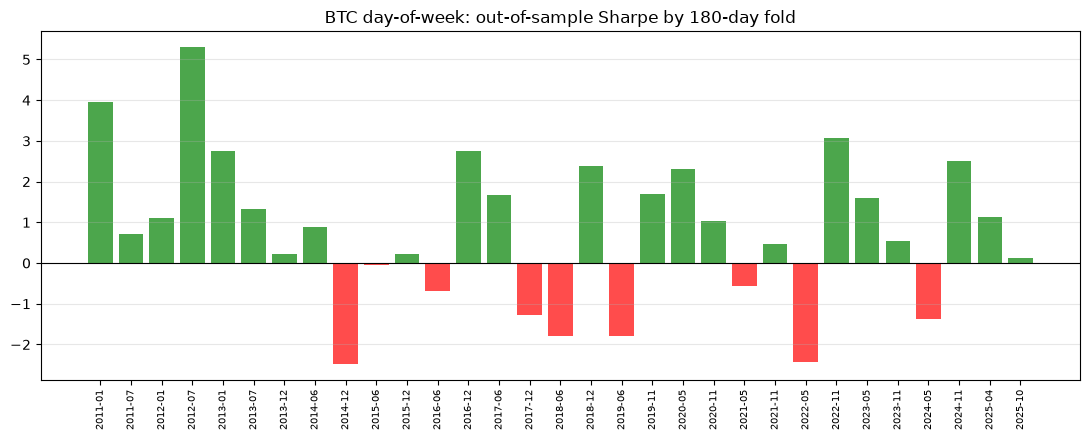

In [4]:
bt = partial(single_asset_backtest, cost_bps=5.0, freq=365)
wf = walk_forward_validation(btc, seasonality_signal, bt, params={"effect": "day_of_week"},
                               train_window=180, test_window=180)
win_rate = (wf["sharpe"] > 0).mean()
print(f"{len(wf)} folds, {win_rate:.1%} with positive Sharpe")

fig, ax = plt.subplots(figsize=(11, 4.5))
colors = ["green" if s > 0 else "red" for s in wf["sharpe"]]
ax.bar(range(len(wf)), wf["sharpe"], color=colors, alpha=0.7)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(range(len(wf)))
ax.set_xticklabels([d.strftime("%Y-%m") for d in wf["fold_start"]], rotation=90, fontsize=7)
ax.set_title("BTC day-of-week: out-of-sample Sharpe by 180-day fold")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("seasonality_walkforward.png", dpi=110)
plt.show()


**71% of folds are positive — genuinely more consistent than most other
strategies in this repo showed on their walk-forward checks**, including
ones with stronger theoretical justification. This is the finding that
keeps this result from being dismissed outright: a spurious,
multiple-comparisons artifact would not typically be expected to show
this level of temporal consistency across 31 independent 180-day windows
spanning very different BTC market regimes (2011 through 2026). That
doesn't resolve the skepticism raised above — it's still one result out
of six tested, on an asset where the underlying economic mechanism is
unclear — but it's a materially stronger piece of evidence than the raw
Sharpe or the confidence interval alone would suggest.

## 4. Discussion: risks and when to use this strategy

**When it might be worth investigating further:** the BTC day-of-week
result specifically — strong Sharpe, CI excluding zero, and unusually
consistent walk-forward performance — is a genuine candidate for deeper
investigation, not dismissal. But "worth investigating further" and
"proven" are different claims, and this notebook only supports the
former.

**When to be skeptical by default:** calendar effects tested without
first pre-registering which specific effect and asset combination is
expected to work, the way this notebook tested six combinations and
reports the strongest one. That workflow — test many things, report the
best one — is precisely the data-mining pattern that has caused many
published calendar anomalies to fail to replicate out of sample.

**Risks and factors:**
- **Multiple-comparisons risk is the central concern for this entire
  strategy category**, more so than for any other strategy in this repo.
  A rigorous version of this research would define the hypothesis before
  looking at the data, or apply a formal multiple-testing correction
  (e.g., Bonferroni) to the significance threshold given how many
  combinations were actually tried.
- **No clear economic mechanism for the strongest result.** A day-of-week
  effect in a market with no calendar-day boundary (BTC trades 24/7) is a
  harder claim to explain than the same pattern would be in equities,
  where institutional flow patterns tied to the traditional trading week
  are well documented.
- **This strategy uses no risk management or position sizing beyond the
  calendar rule itself** — unlike every other strategy in this repo, it
  doesn't respond to price action at all, which is both its defining
  feature and a real limitation if the underlying pattern ever
  shifts or decays.
- **A real next step:** test the BTC day-of-week effect against a
  completely fresh, later out-of-sample period not used in any of the
  analysis above, and consider whether crypto-specific explanations
  (e.g., weekly settlement or reporting cycles at large exchanges/funds)
  offer a plausible mechanism before treating the pattern as tradeable.
